# Visualisations and statistical analysis
## Stacked barplots

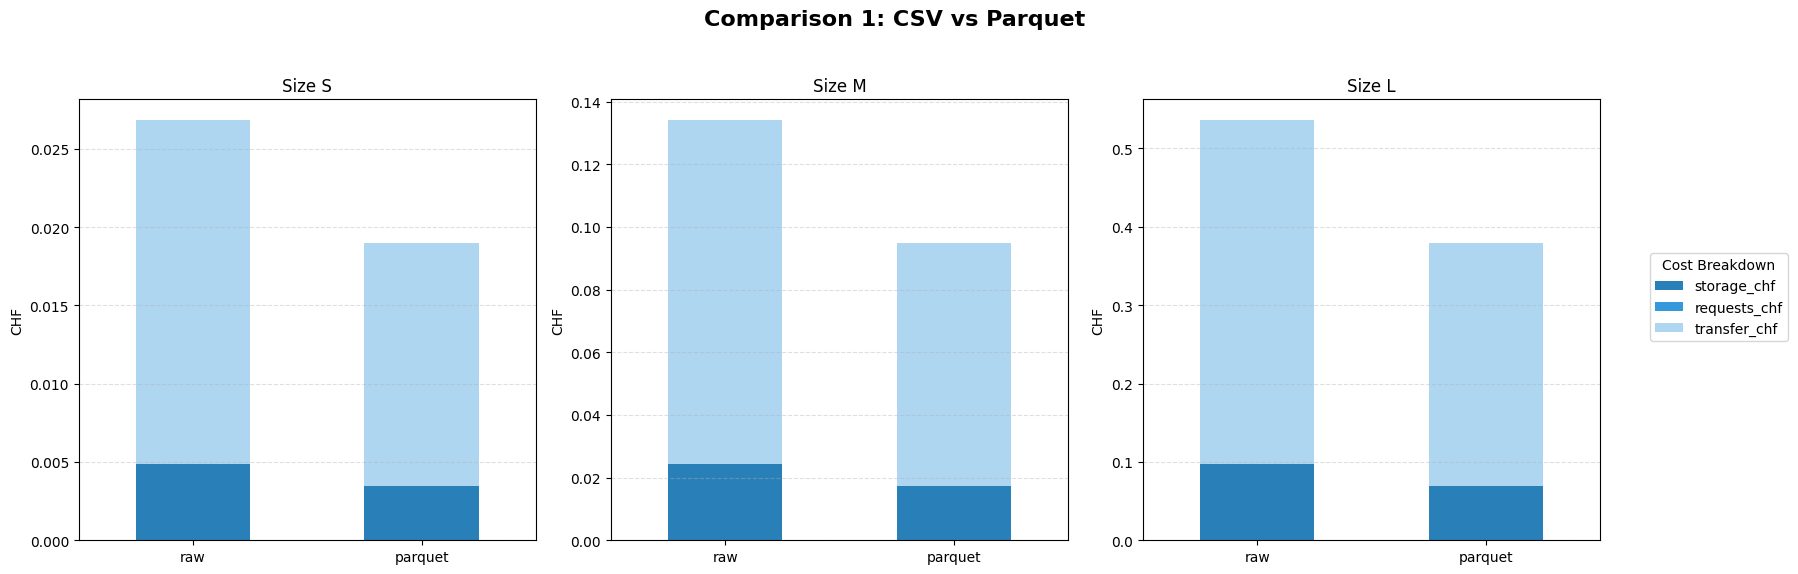

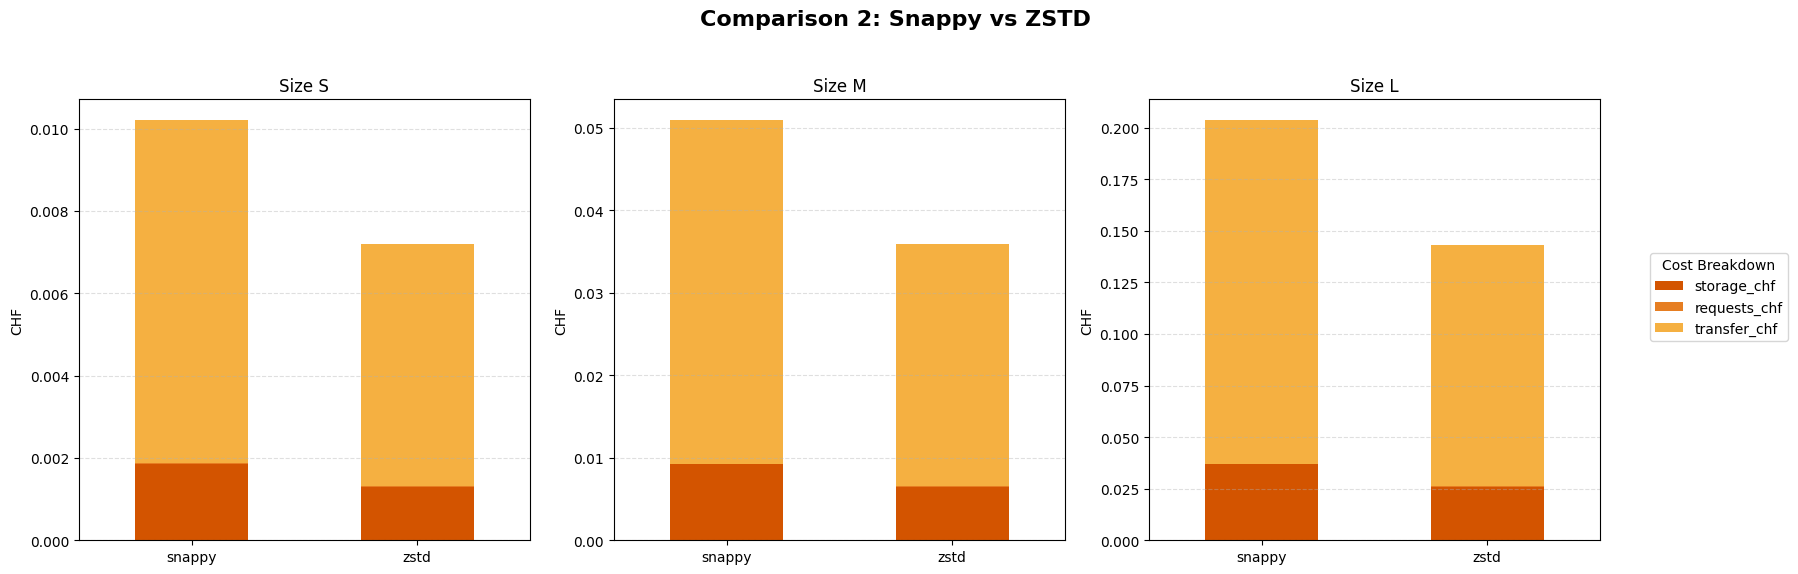

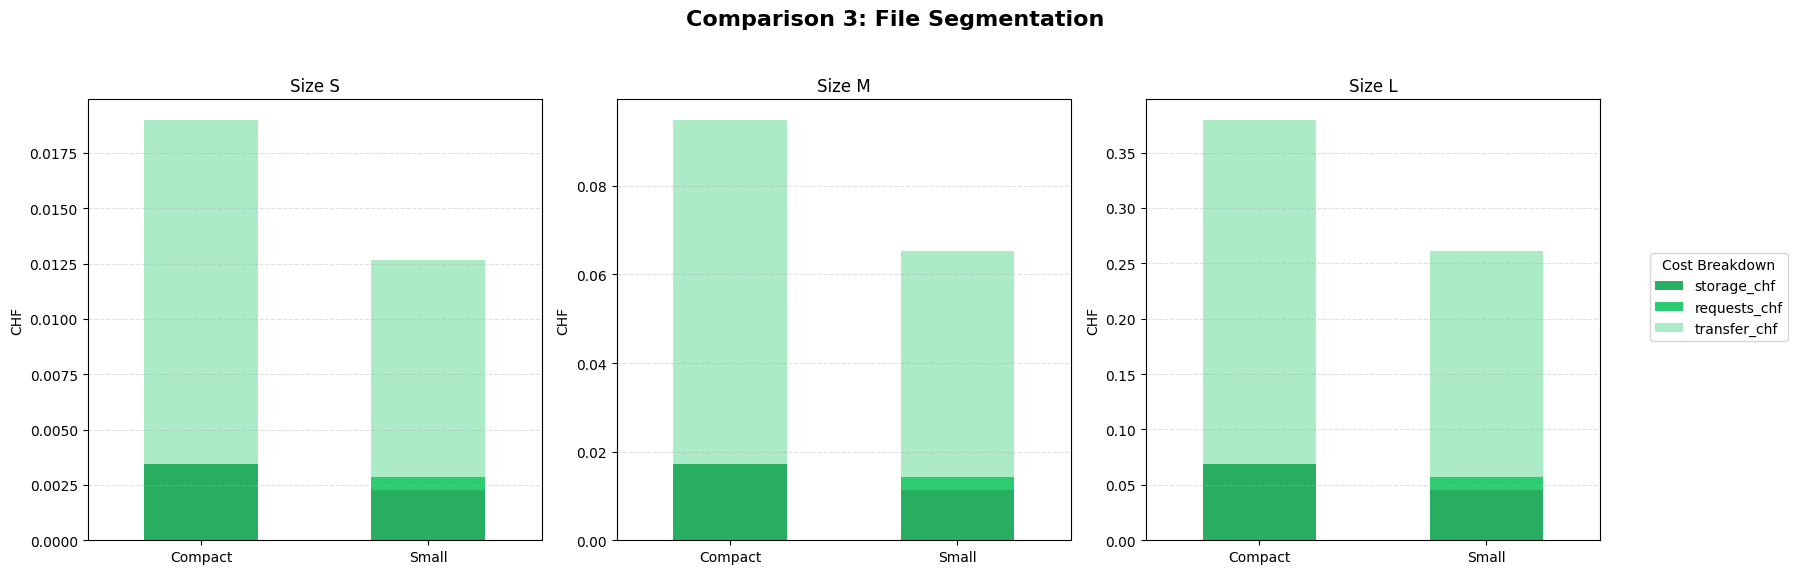

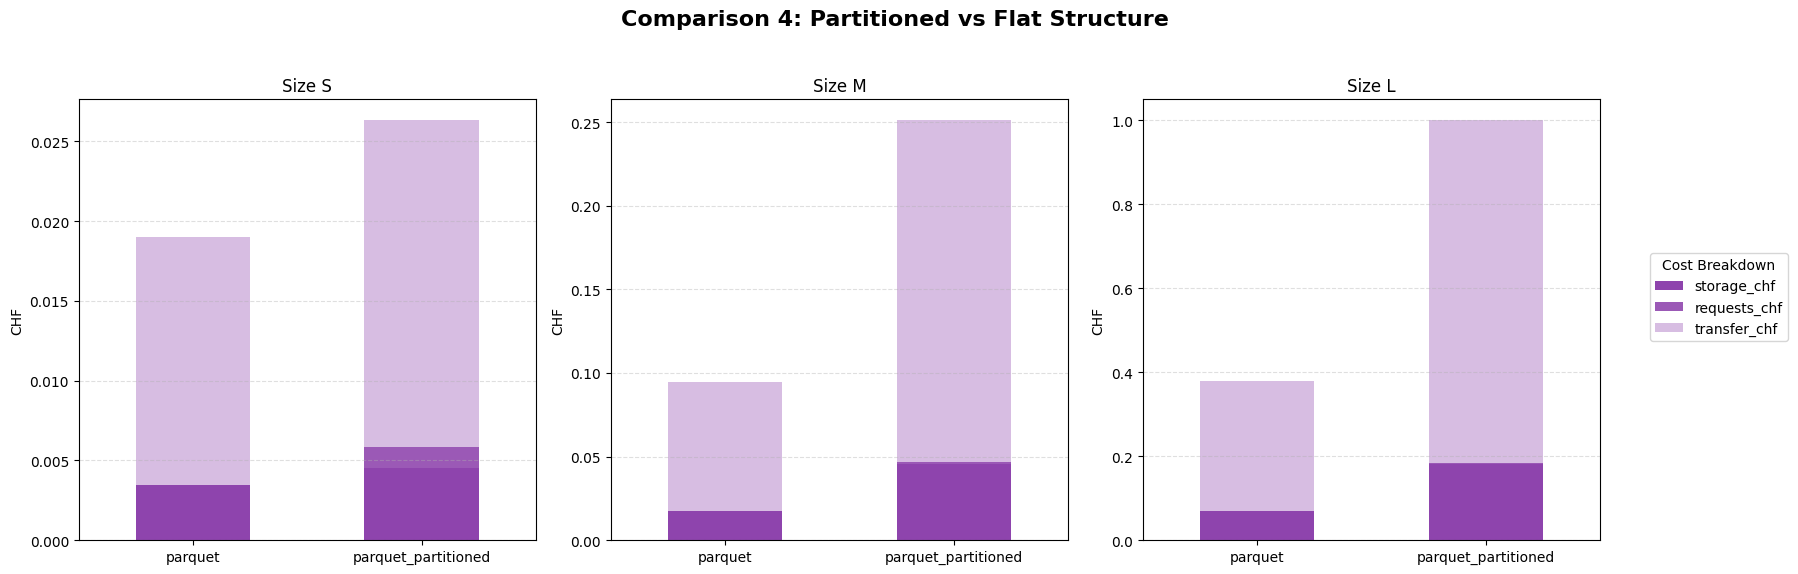

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the data
df = pd.read_csv('results.csv')

def plot_side_by_side(df, filter_logic, x_col, main_title, color_palette):
    dataset_sizes = ['S', 'M', 'L']
    cost_cols = ['storage_chf', 'requests_chf', 'transfer_chf']
    
    # Create a figure with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(main_title, fontsize=16, fontweight='bold')

    for i, size in enumerate(dataset_sizes):
        subset = df[df['label'] == size].copy()
        subset = filter_logic(subset)
        
        if not subset.empty:
            # We use the color_palette passed in the function call
            subset.set_index(x_col)[cost_cols].plot(
                kind='bar', stacked=True, ax=axes[i], color=color_palette, legend=False
            )
            axes[i].set_title(f'Size {size}', fontsize=12)
            axes[i].set_ylabel('CHF')
            axes[i].set_xlabel('')
            axes[i].tick_params(axis='x', rotation=0)
            axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        else:
            axes[i].set_title(f'Size {size} (No Data)')

    # Add a single legend for the whole row
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Cost Breakdown", loc='center right', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95]) 
    plt.show()

# --- DEFINE COLOR PALETTES (Storage, Requests, Transfer) ---
# Each palette has a different "vibe" to distinguish the sections of your report
blue_palette = ['#2980b9', '#3498db', '#aed6f1']   # Blues
orange_palette = ['#d35400', '#e67e22', '#f5b041'] # Oranges/Browns
green_palette = ['#27ae60', '#2ecc71', '#abebc6']  # Greens
purple_palette = ['#8e44ad', '#9b59b6', '#d7bde2'] # Purples

# --- 1. CSV vs Parquet ---
def filter_format(d):
    return d[(d['n_files'] == 1) & 
             ((d['variant'] == 'raw') | ((d['variant'] == 'parquet') & (d['compression'] == 'none')))]

plot_side_by_side(df, filter_format, 'variant', 'Comparison 1: CSV vs Parquet', blue_palette)

# --- 2. Snappy vs ZSTD ---
def filter_compression(d):
    return d[(d['variant'] == 'parquet') & (d['compression'] != 'none')]

plot_side_by_side(df, filter_compression, 'compression', 'Comparison 2: Snappy vs ZSTD', orange_palette)

# --- 3. Small Files vs Compact ---
def filter_segmentation(d):
    sub = d[((d['variant'] == 'parquet') & (d['compression'] == 'none')) | (d['variant'] == 'parquet_small')].copy()
    sub['sizing'] = sub['n_files'].apply(lambda x: "Small" if x > 1 else "Compact")
    return sub

plot_side_by_side(df, filter_segmentation, 'sizing', 'Comparison 3: File Segmentation', green_palette)

# --- 4. Partitioning vs Flat ---
def filter_partition(d):
    return d[((d['variant'] == 'parquet') & (d['compression'] == 'none')) | (d['variant'] == 'parquet_partitioned')]

plot_side_by_side(df, filter_partition, 'variant', 'Comparison 4: Partitioned vs Flat Structure', purple_palette)

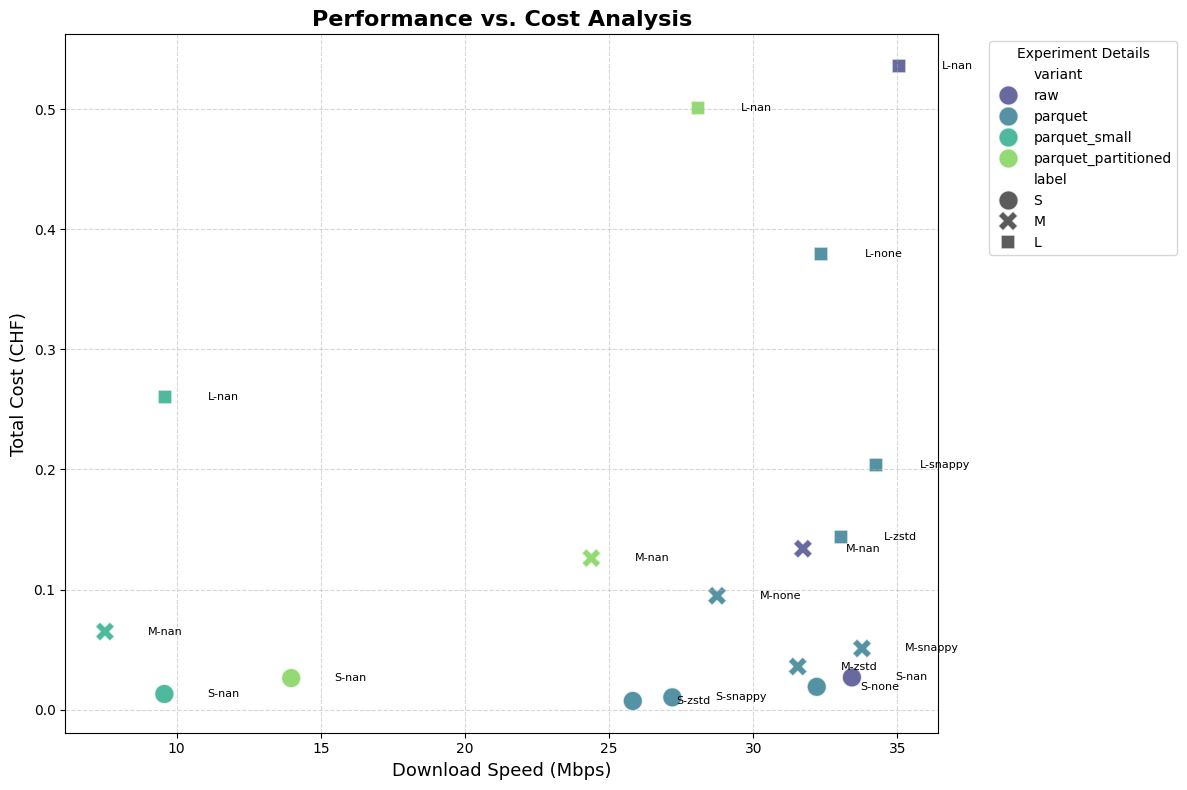

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your results
# df = pd.read_csv('results.csv')

# 2. Plotting
plt.figure(figsize=(12, 8))

# Use scatterplot to show individual experiment results
sns.scatterplot(
    data=df, 
    x='dl_mbps', 
    y='total_chf', 
    hue='variant',      # Color by Format (CSV vs Parquet)
    style='label',      # Different shapes for S, M, L sizes
    s=200,              # Make the points large and visible
    alpha=0.8,          # Slight transparency for overlapping points
    palette='viridis'   # Professional color palette
)

# 3. Styling and Labels
plt.title('Performance vs. Cost Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Download Speed (Mbps)', fontsize=13)
plt.ylabel('Total Cost (CHF)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a legend outside the plot area
plt.legend(title='Experiment Details', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Adding Annotations (Optional)
# This adds text labels to the points so you can identify them easily
for i in range(df.shape[0]):
    plt.text(
        df.dl_mbps.iloc[i] + 1.5, 
        df.total_chf.iloc[i], 
        f"{df.label.iloc[i]}-{df.compression.iloc[i]}", 
        fontsize=8, 
        va='center'
    )

plt.tight_layout()
plt.savefig('performance_scatter_plot.png')
plt.show()

In [11]:
import pandas as pd
import statsmodels.api as sm

# 1. Load data
df = pd.read_csv('results.csv')

# 2. Manually set the baseline for Label and Variant
# The first item in the 'categories' list becomes the baseline
df['label'] = pd.Categorical(df['label'], categories=['S', 'M', 'L'], ordered=True)
df['variant'] = pd.Categorical(df['variant'], categories=['raw', 'parquet', 'parquet_small', 'parquet_partitioned'], ordered=True)

# 3. Perform encoding
# 'label_S' and 'variant_raw' will be dropped
df_encoded = pd.get_dummies(df, columns=['label', 'variant', 'compression'], drop_first=True)

# 4. Define your X variables based on the remaining columns
X = df_encoded[[
    'stored_mb', 
    'n_files', 
    'label_M', 
    'label_L', 
    'variant_parquet', 
    'variant_parquet_small', 
    'variant_parquet_partitioned', 
    'compression_snappy', 
    'compression_zstd'
]]

y = df_encoded['total_chf']
X = sm.add_constant(X)

# 5. Fit and Print
model = sm.OLS(y, X.astype(float)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              total_chf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.477e+06
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.15e-25
Time:                        14:33:23   Log-Likelihood:                 136.46
No. Observations:                  18   AIC:                            -252.9
Df Residuals:                       8   BIC:                            -244.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             